# Projeto: Detecção de Fraudes em Cartões de Crédito

Neste projeto, iremos criar um modelo de Machine Learning capaz de identificar fraudes em transações de cartão de crédito.

## 1. Importando as Bibliotecas
O primeiro passo é importar as ferramentas do Python que vamos usar para ler e visualizar os dados.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações visuais dos gráficos
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Carregando os Dados
Agora vamos carregar o arquivo `creditcard.csv` que baixamos.

In [3]:
df = pd.read_csv('creditcard.csv')

# Exibir as 5 primeiras linhas para ver se funcionou
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# Contando as fraudes (A coluna 'Class' diz se é fraude ou não. 0 = Normal, 1 = Fraude)
print("Distribuição das transações:")
print(df['Class'].value_counts())

print("\nPorcentagem de fraudes:")
porcentagem = (df[df['Class'] == 1].shape[0] / df.shape[0]) * 100
print(f"{porcentagem:.4f}%")


Distribuição das transações:
Class
0    284315
1       492
Name: count, dtype: int64

Porcentagem de fraudes:
0.1727%


In [5]:
Exatamente assim! E veja só a resposta que ele nos deu:

* **284.315** transações normais (Class 0).
* **492** transações com fraude (Class 1).
* Apenas **0,17%** dos dados são fraudes!

Aqui está o grande "ponto cego" que te falei no guia: se você criar uma IA agora que seja "preguiçosa" e simplesmente classifique *todas* as transações do mundo como seguras (0), ela vai ter uma acurácia de 99,82%! O chefe olharia e diria "Nossa, a IA está perfeita!". Mas na vida real, o banco iria falir, porque **todas as 492 fraudes passariam despercebidas**.

Por isso, nós vamos precisar ensinar ela a focar nas fraudes. Mas antes de usar a inteligência artificial, precisamos preparar o terreno (**Passo 3** do guia).

### Passo 3: Preparação dos Dados (Train/Test Split)
Nós precisamos separar os dados em dois grupos: um grupo para **treinar** a IA (como se fossem os livros de estudo dela) e outro para **testar** (como se fosse a prova final). E também vamos padronizar o valor do dinheiro (para a IA não confundir uma compra de R$ 1,00 com uma de R$ 10.000,00).

Crie uma nova caixinha `+` e rode este código abaixo:

```python
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 1. Padronizando os Valores e o Tempo
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['Time'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))

# 2. Separando a Resposta (y) do resto dos dados (X)
# X = As transações / y = O gabarito (se é fraude ou não)
X = df.drop('Class', axis=1)
y = df['Class']

# 3. Dividindo 80% para Treinar e 20% para a Prova Final (Teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Dados preparados e divididos com sucesso!")
print(f"Tamanho do Treino: {X_train.shape[0]} transações")
print(f"Tamanho do Teste (Prova Final): {X_test.shape[0]} transações")
```

Ele vai preparar os dados em frações de segundo. Me dê um ok quando essa parte der a mensagem de "sucesso"!

SyntaxError: invalid syntax (3896286682.py, line 1)

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['Time'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Dados preparados e divididos com sucesso!")
print(f"Tamanho do Treino: {X_train.shape[0]} transações")
print(f"Tamanho do Teste (Prova Final): {X_test.shape[0]} transações")


Dados preparados e divididos com sucesso!
Tamanho do Treino: 227845 transações
Tamanho do Teste (Prova Final): 56962 transações


In [7]:
from imblearn.under_sampling import RandomUnderSampler
from sklearn.linear_model import LogisticRegression

# 1. Balanceando os dados de Treino (deixando 50% / 50%)
rus = RandomUnderSampler(random_state=42)
X_train_balanceado, y_train_balanceado = rus.fit_resample(X_train, y_train)

# 2. Criando a nossa Inteligência Artificial (Modelo Matemático)
modelo = LogisticRegression()

# 3. Treinando a IA! (Dando o material balanceado pra ela estudar)
modelo.fit(X_train_balanceado, y_train_balanceado)

# 4. Pedindo para a IA fazer a "Prova Final" (com os dados de Teste que ela nunca viu)
previsoes = modelo.predict(X_test)

print("IA treinada com sucesso!")
print("\nVeja como os dados de estudo ficaram perfeitamente balanceados:")
print(y_train_balanceado.value_counts())


IA treinada com sucesso!

Veja como os dados de estudo ficaram perfeitamente balanceados:
Class
0    394
1    394
Name: count, dtype: int64


RELATÓRIO FINAL DA NOSSA INTELIGÊNCIA ARTIFICIAL:

              precision    recall  f1-score   support

           0       1.00      0.96      0.98     56864
           1       0.04      0.92      0.07        98

    accuracy                           0.96     56962
   macro avg       0.52      0.94      0.53     56962
weighted avg       1.00      0.96      0.98     56962



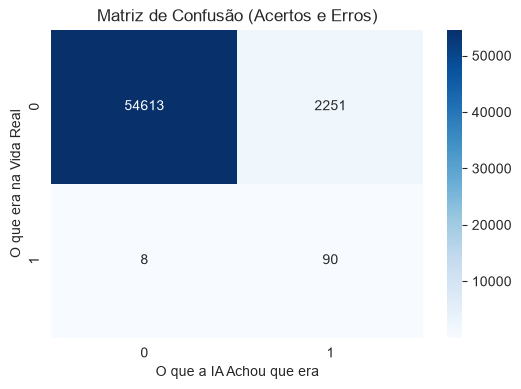

In [8]:
from sklearn.metrics import classification_report, confusion_matrix

# 1. O "Boletim" com as notas
print("RELATÓRIO FINAL DA NOSSA INTELIGÊNCIA ARTIFICIAL:\n")
print(classification_report(y_test, previsoes))

# 2. Desenhando o Gráfico de Acertos e Erros (Matriz de Confusão)
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, previsoes), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão (Acertos e Erros)')
plt.ylabel('O que era na Vida Real')
plt.xlabel('O que a IA Achou que era')
plt.show()
